# Table of Contents

## 1. Introduction

### 1.1 Introduction to Deep Learning

### 1.2 Problem Statement

### 1.3 Motivation for Choosing the Project

### 1.4 Project Objectives

### 1.5 Real-World Applications

## 2. Dataset Description

##2.1 Indian Traffic Sign Dataset

### 2.2 Indian Traffic Sign Dataset

### 2.3 Sample Images from the Dataset

## 3. Data Preprocessing

### 3.1 Importing Required Libraries

### 3.2 Loading the Dataset

### 3.3 Image Resizing

### 3.4 Image Normalization

### 3.5 Label Encoding

### 3.6 Data Splitting

### 3.7 Data Augmentation

## 4. Convolutional Neural Network (CNN)

### 4.1 Introduction to CNN

### 4.2 CNN Architecture

### 4.3 CNN Model Summary

### 4.4 CNN Training

### 4.5 CNN Evaluation

### 4.6 CNN Results

## 5. Performance Comparison

### 5.1 CNN vs ResNet

### 5.2 Accuracy Comparison

### 5.3 Computational Efficiency Comparison

## 6. Challenges Faced

## 7. Key Learnings

## 8. Future Scope

## 9. Conclusion

## 10. References


# 1. **Introduction**

## 1.1 **Introduction to Deep Learning**

Deep Learning is a subset of Machine Learning that enables computers to learn patterns directly from data without requiring manual feature extraction. It is inspired by the structure and functioning of the human brain and uses Artificial Neural Networks with multiple layers to process information.

In recent years, deep learning has gained significant attention due to its ability to solve complex problems involving images, speech, text, and videos. Among various deep learning architectures, Convolutional Neural Networks (CNNs) have proven to be highly effective for image classification tasks because they can automatically learn important visual features from images.

Deep learning techniques are widely used in many real-world applications such as facial recognition, medical image analysis, autonomous vehicles, and traffic management systems. In this project, deep learning models are utilized to recognize and classify traffic signs from German and Indian traffic sign datasets, contributing to the development of intelligent transportation systems and safer driving environments.


## 1.2 **Problem Statement**

Traffic signs play a crucial role in ensuring road safety by providing important information and instructions to drivers. However, drivers may sometimes fail to notice or correctly interpret traffic signs due to factors such as distractions, poor lighting conditions, adverse weather, or driver fatigue. Missing critical signs like speed limits, stop signs, or warning signs can lead to accidents and traffic violations.

With the growing interest in autonomous vehicles and intelligent transportation systems, there is a need for automated systems that can accurately detect and recognize traffic signs in real time. Developing a reliable traffic sign recognition system can assist drivers, enhance road safety, and contribute to the advancement of self-driving technologies.

This project aims to address this challenge by developing a deep learning-based traffic sign recognition system capable of classifying traffic signs from both German and Indian traffic sign datasets using Convolutional Neural Networks (CNN) and Transfer Learning with ResNet.


## 1.3 **Project Objectives**

The main objectives of this project are:

* To develop an automated traffic sign recognition system using deep learning techniques.
* To implement and train a Convolutional Neural Network (CNN) model for traffic sign classification.
* To apply Transfer Learning using the ResNet architecture and evaluate its performance.
* To compare the effectiveness of CNN and ResNet models based on classification accuracy and computational efficiency.
* To analyze the applicability of deep learning models in intelligent transportation systems and autonomous driving applications.


## 1.4 **Real-World Applications**

Traffic Sign Recognition systems have numerous practical applications in modern transportation and road safety systems. Some of the key applications include:

### Autonomous Vehicles

Self-driving cars rely on traffic sign recognition systems to understand and obey road regulations, such as speed limits, stop signs, and warning signs.

### Advanced Driver Assistance Systems (ADAS)

Traffic sign recognition can assist drivers by providing real-time alerts about important traffic signs, reducing the chances of missing critical information.

### Intelligent Transportation Systems (ITS)

Traffic sign recognition contributes to the development of smart transportation systems by enabling efficient traffic monitoring and management.

### Road Safety Enhancement

Automated recognition of traffic signs can help reduce accidents caused by driver fatigue, distractions, or poor visibility conditions.

### Traffic Monitoring and Surveillance

Traffic authorities can utilize traffic sign recognition systems for road monitoring, infrastructure assessment, and traffic analysis.


# **2.** **Dataset Description**

# **2.2 Indian Traffic Sign Dataset**

The Indian Traffic Sign Dataset was utilized to assess the performance of deep learning models on traffic signs commonly encountered on Indian roads. The dataset consists of 59 traffic sign classes with images collected under diverse environmental conditions, including varying illumination, occlusions, and background complexities. Incorporating this dataset enables the evaluation of model robustness and generalization across traffic signs from different regions.

## 2.2 Sample Images from the Dataset

Visualizing sample images from the datasets helps in understanding the diversity of traffic signs and the challenges involved in their classification. The datasets contain images captured under varying environmental conditions, including different illumination levels, viewpoints, backgrounds, and weather conditions.

The following samples provide an overview of the traffic sign categories used for training and evaluating the proposed models.


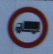
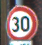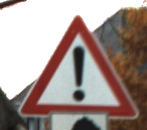

# **3. Data Preprocessing**

Deep learning models cannot directly work with raw images. Therefore, several preprocessing techniques are applied to prepare the data for training

### **3.1 Importing Required Libraries**

Python provides numerous libraries for building and training deep learning models. In this project, TensorFlow and Keras are used for implementing neural network architectures, OpenCV is employed for image processing tasks, NumPy is utilized for numerical computations, and Matplotlib is used for data visualization. Additional libraries such as Pandas and Scikit-learn assist in data handling and model evaluation.


In [ ]:
# Core libraries
import os
import numpy as np
import pandas as pd
import random
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Scikit-learn for data splitting and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# TensorFlow and Keras for deep learning
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     BatchNormalization, Activation, GlobalAveragePooling2D)
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint

# **3.2 Loading the Dataset**

The datasets are organized into class-specific folders, where each folder corresponds to a particular traffic sign category. During this step, all images are read from their respective directories, assigned labels based on their class, and stored in arrays for further processing.

Loading the dataset in a structured manner ensures efficient handling of large image collections and facilitates subsequent preprocessing operations.


In [ ]:
# Mounting the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#unzipping the data folder
import shutil
import zipfile
import os
# 1. Clear out the old, messy directory completely
if os.path.exists('/content/IndianDataset'):
    shutil.rmtree('/content/IndianDataset')

# 2. Extract to the ROOT folder ('/content/'), NOT inside 'Train'
zip_path = '/content/drive/MyDrive/IndianDataset/Indian.zip'
data_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_path)

print("Dataset re-extracted cleanly!")

Dataset re-extracted cleanly!


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'drive', 'Indian-Traffic Sign-Dataset', 'sample_data']


In [ ]:
print(os.listdir('/content/Indian-Traffic Sign-Dataset'))

['Images', 'traffic_sign.csv']


In [ ]:
# Load CSV file
df = pd.read_csv('/content/Indian-Traffic Sign-Dataset/traffic_sign.csv')

# Show first 5 rows
df.head()

,ClassId,Name
0,0,Give way
1,1,No entry
2,2,One-way traffic
3,3,One-way traffic
4,4,No vehicles in both directions


In [ ]:
print(df.columns)

print("Total Classes:", len(df))

Index(['ClassId', 'Name'], dtype='object')
Total Classes: 59


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   ClassId  59 non-null     int64 
 1   Name     59 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


Image Shape: (32, 32, 3)


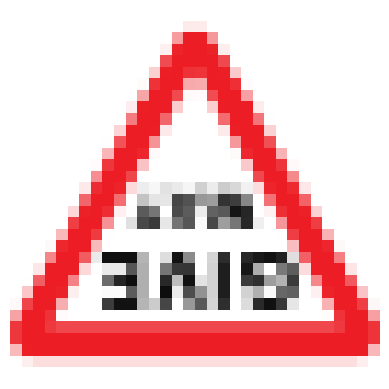

In [ ]:
# Get the ClassId for the first entry in the DataFrame
class_id = df.iloc[0]['ClassId']

# Construct the path to the directory containing images for this ClassId
# Assuming images are in /content/Indian-Traffic Sign-Dataset/Images/<ClassId>/
# and we'll pick the first image found in that directory.
images_base_dir = '/content/Indian-Traffic Sign-Dataset/Images'
class_images_dir = os.path.join(images_base_dir, str(class_id))

# Get a list of files in the class directory
image_files = os.listdir(class_images_dir)

if image_files:
    # Pick the first image file
    first_image_file = image_files[0]
    img_path = os.path.join(class_images_dir, first_image_file)

    img = cv2.imread(img_path)

    # Check if the image was loaded successfully
    if img is not None:
        print("Image Shape:", img.shape)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
    else:
        print(f"Error: Could not load image from {img_path}")
elif os.path.exists(class_images_dir):
    print(f"Error: No images found in directory {class_images_dir}")
else:
    print(f"Error: Class directory not found: {class_images_dir}")

### **3.3 Image Resizing**

Traffic sign images in the datasets have varying dimensions. Since deep learning models require input images of a fixed size, all images are resized to a uniform resolution. This standardization reduces computational complexity and ensures consistency during model training and inference.


In [ ]:
#Load and Preprocess ALL Images

#Create Empty Lists
X = []
y = []

#Load the images
IMG_SIZE = 64
images_base_dir = '/content/Indian-Traffic Sign-Dataset/Images'
for class_folder in os.listdir(images_base_dir):
    class_path = os.path.join(images_base_dir, class_folder)
    # Skip non-folder files
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        # Read image
        img = cv2.imread(img_path)
        # Skip broken images
        if img is None:
            continue
        # Resize image
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Store image
        X.append(img)
        # Store label
        y.append(int(class_folder))

#covert list to array
X = np.array(X)
y = np.array(y)

print("Total Images Shape:", X.shape)
print("Total Labels Shape:", y.shape)

Total Images Shape: (13971, 64, 64, 3)
Total Labels Shape: (13971,)


## 3.4 Image Normalization

Image normalization is performed by scaling pixel intensity values from the range of 0–255 to 0–1. Normalization helps improve model convergence, accelerates training, and prevents numerical instability during optimization.

##**Data** **Augmentation**

Data augmentation is a preprocessing technique used to artificially increase the diversity of training images by applying random transformations such as rotation, zooming, shifting, and flipping. This technique helps improve the robustness and generalization capability of deep learning models by exposing them to various image variations. In this project, data augmentation was employed to reduce overfitting and enhance the model's ability to recognize traffic signs under different environmental conditions.



In [ ]:
# Noramalization and Augmentation

X = X / 255.0

datagen = ImageDataGenerator(

    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

### **Data Splitting**

To evaluate the performance of the models fairly, the dataset is divided into training, validation, and testing subsets. The training set is used to learn model parameters, the validation set helps monitor model performance during training, and the testing set provides an unbiased assessment of the final model.


In [ ]:
#Train , validation and test Split
X_train, X_temp, y_train, y_temp = train_test_split(  X,y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training Set :", X_train.shape)
print("Validation Set :", X_val.shape)
print("Testing Set :", X_test.shape)
print('-----------------------------')
print("Training Labels :", y_train.shape)
print("Validation Labels :", y_val.shape)
print("Testing Labels :", y_test.shape)

Training Set : (9779, 64, 64, 3)
Validation Set : (2096, 64, 64, 3)
Testing Set : (2096, 64, 64, 3)
-----------------------------
Training Labels : (9779,)
Validation Labels : (2096,)
Testing Labels : (2096,)


## 3.5 Label Encoding

Traffic sign categories are represented by numerical labels. These labels are converted into one-hot encoded vectors to enable the models to perform multi-class classification effectively. One-hot encoding ensures that each traffic sign class is represented uniquely.


In [ ]:
#Hot-Encoding
# Total number of classes
num_classes = np.max(y) + 1
print("Number of Classes:", num_classes)
# Encode ONLY if labels are not already one-hot encoded
if len(y_train.shape) == 1:
    y_train = to_categorical(y_train, num_classes)
    y_val = to_categorical(y_val, num_classes)
    y_test = to_categorical(y_test, num_classes)

    print("One-hot encoding applied successfully!")

else:
    print("Labels are already one-hot encoded.")

# Verify shapes
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

Number of Classes: 59
One-hot encoding applied successfully!
y_train shape: (9779, 59)
y_val shape: (2096, 59)
y_test shape: (2096, 59)


# **4. Convolutional Neural Network (CNN)**


##4.1 **Introduction to CNN**

Convolutional Neural Networks (CNNs) are a class of deep learning models specifically designed for processing image data. CNNs automatically learn hierarchical features from images, ranging from simple edges and textures to complex patterns and shapes. Due to their ability to capture spatial information effectively, CNNs have become one of the most widely used architectures for image classification tasks.

In this project, a custom CNN model was developed to classify traffic signs from the German and Indian traffic sign datasets. The CNN model serves as a baseline approach and its performance is compared with a Transfer Learning model based on the ResNet50 architecture.

##4.2 **CNN Architecture**

4.2 CNN Architecture

The proposed Convolutional Neural Network (CNN) architecture was designed to effectively extract and learn discriminative features from traffic sign images. The model accepts input images of size 64 × 64 × 3 and consists of two convolutional blocks followed by fully connected layers for classification.

The architecture is composed of the following layers:

Input Layer
Input image size: 64 × 64 × 3

First Convolutional Layer
32 filters
Kernel size: 3 × 3

Activation function: ReLU
Responsible for extracting low-level features such as edges, corners, and textures.

Batch Normalization Layer
Normalizes feature distributions during training.
Helps stabilize and accelerate the learning process.

First Max-Pooling Layer
Pool size: 2 × 2
Reduces the spatial dimensions of feature maps and decreases computational complexity.

Second Convolutional Layer
64 filters
Kernel size: 3 × 3

Activation function: ReLU
Learns higher-level and more complex visual features.

Batch Normalization Layer
Improves model convergence and training stability.

Second Max-Pooling Layer
Pool size: 2 × 2
Further reduces feature map dimensions while preserving important information.

Flatten Layer
Converts the two-dimensional feature maps into a one-dimensional feature vector.

Fully Connected Dense Layer
128 neurons

Activation function: ReLU
Learns task-specific representations for traffic sign classification.

Dropout Layer
Dropout rate: 0.5
Randomly deactivates neurons during training to reduce overfitting.

Output Layer
Number of neurons: 59

Activation function: Softmax
Produces probability scores for each traffic sign class.

## 4.3 **CNN Model Summary**

The CNN model was designed to learn discriminative visual features directly from traffic sign images. The architecture includes convolutional layers followed by activation functions, pooling operations, dropout regularization, and dense layers. The final output layer consists of neurons equal to the number of traffic sign categories and uses the Softmax activation function to predict class probabilities.

(You can insert the output of model.summary() below this section.)

In [ ]:
#Building the model

# Ensure num_classes is a standard Python int
num_classes = int(num_classes)

model = Sequential()

# First Convolution Layer
# Correct input_shape to match IMG_SIZE (64,64,3)
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,3)))

model.add(BatchNormalization())

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64,(3,3),activation='relu'))

model.add(BatchNormalization())

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 59)             │         7,611 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633,147 (6.23 MB)

 Trainable params: 1,632,955 (6.23 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
#Compile

#optimizer
optimizer=RMSprop(
    learning_rate=0.001,
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True

)

# **4.4 CNN Training**

The CNN model was trained using the processed traffic sign datasets for 20 epochs. The Adam optimizer was employed with an appropriate learning rate, while categorical cross-entropy was used as the loss function. During training, validation data was utilized to monitor model performance and prevent overfitting. The objective of the training process was to minimize classification errors and improve prediction accuracy.

In [ ]:
#training the model
history = model.fit(X_train,
y_train,

    validation_data=(X_val, y_val),

    epochs=20,

    batch_size=32,

    callbacks=[early_stop]
)

Epoch 1/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8498 - loss: 0.4833 - val_accuracy: 0.7772 - val_loss: 0.8037
Epoch 2/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8480 - loss: 0.4815 - val_accuracy: 0.8001 - val_loss: 0.9002
Epoch 3/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8562 - loss: 0.4569 - val_accuracy: 0.7977 - val_loss: 1.1597
Epoch 4/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8613 - loss: 0.4535 - val_accuracy: 0.8087 - val_loss: 0.9985
Epoch 5/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8589 - loss: 0.4572 - val_accuracy: 0.8182 - val_loss: 1.0789
Epoch 6/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8634 - loss: 0.4450 - val_accuracy: 0.8144 - val_loss: 0.8067
Epoch 7/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8681 - loss: 0.4294 - val_accuracy: 0.8020 - val_loss: 0.7355
Epoch 8/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8696 - loss: 0.4280 - val_accuracy: 0

# **4.5 CNN Results**

# **Figure1 : Accuracy Curve**

Figure 5.1 illustrates the training and validation accuracy obtained during the training process. The training accuracy gradually increased from 47.5% to 90.57%, while the validation accuracy improved from 68.2% to 89.26%, indicating effective learning and convergence of the model.

# **Figure 2: Loss Curve**

Figure 5.2 presents the training and validation loss curves. The training loss decreased significantly from approximately 2.06 to 0.26, whereas the validation loss stabilized around 0.36, suggesting that the model successfully minimized classification errors while maintaining acceptable generalization performance.

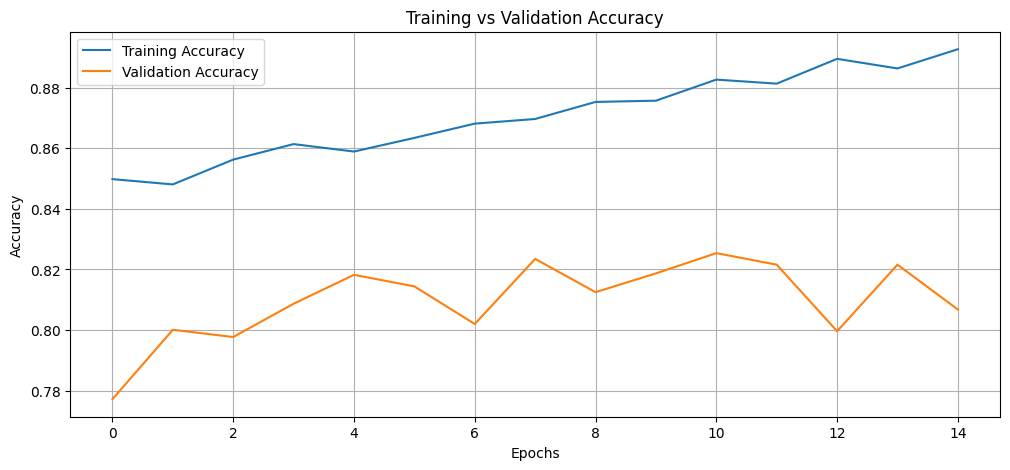

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

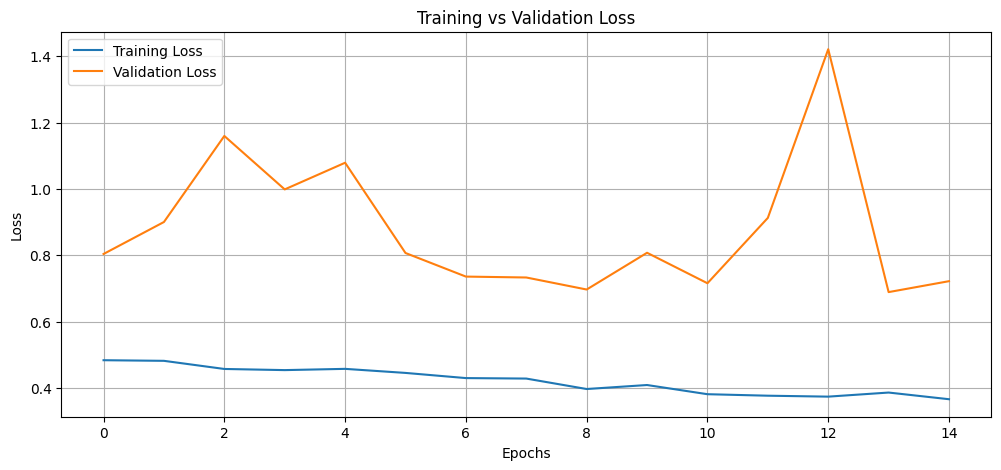

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

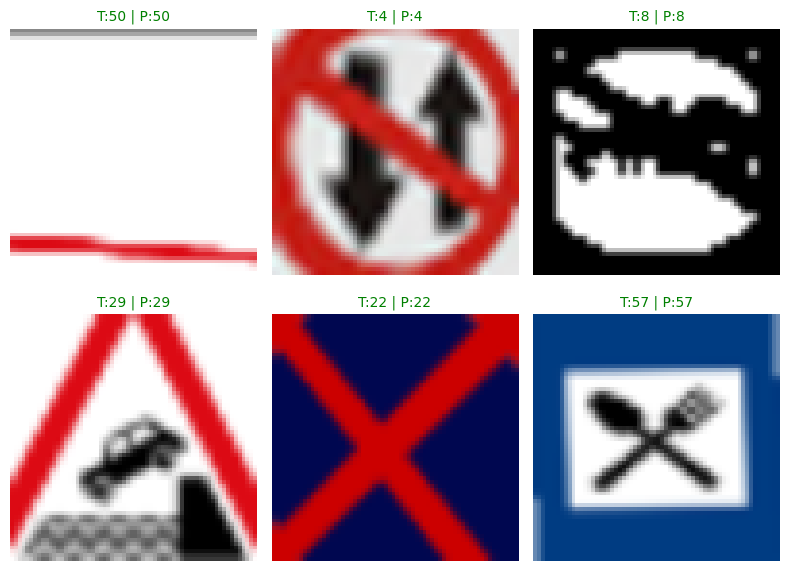

In [ ]:
#Random testing

import random
import numpy as np
import matplotlib.pyplot as plt

# Number of images
num_images = 6

# Smaller figure size
plt.figure(figsize=(8,6))

for i in range(num_images):

    # Random image
    random_index = random.randint(0, len(X_test)-1)

    sample_image = X_test[random_index]

    # True label
    true_label = np.argmax(y_test[random_index])

    # Prediction
    prediction = model.predict(
        np.expand_dims(sample_image, axis=0),
        verbose=0
    )

    predicted_label = np.argmax(prediction)

    # Plot
    plt.subplot(2,3,i+1)

    plt.imshow(sample_image)

    # Color title
    color = "green" if true_label == predicted_label else "red"

    plt.title(
        f"T:{true_label} | P:{predicted_label}",
        fontsize=10,
        color=color
    )

    plt.axis("off")

# Better spacing
plt.tight_layout()

plt.show()

# **4.5 CNN Evaluation**

The performance of the CNN model was evaluated using accuracy, precision, recall, F1-score, confusion matrix, and loss metrics. The model achieved a training accuracy of 89.26% and a validation accuracy of 80.68%. The weighted precision, recall, and F1-score obtained from the classification report were 0.81, 0.78, and 0.78, respectively.

The training and validation accuracy curves indicate steady learning throughout the training process. However, a slight gap between training and validation performance suggests minor overfitting, which is common in custom CNN architectures.

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


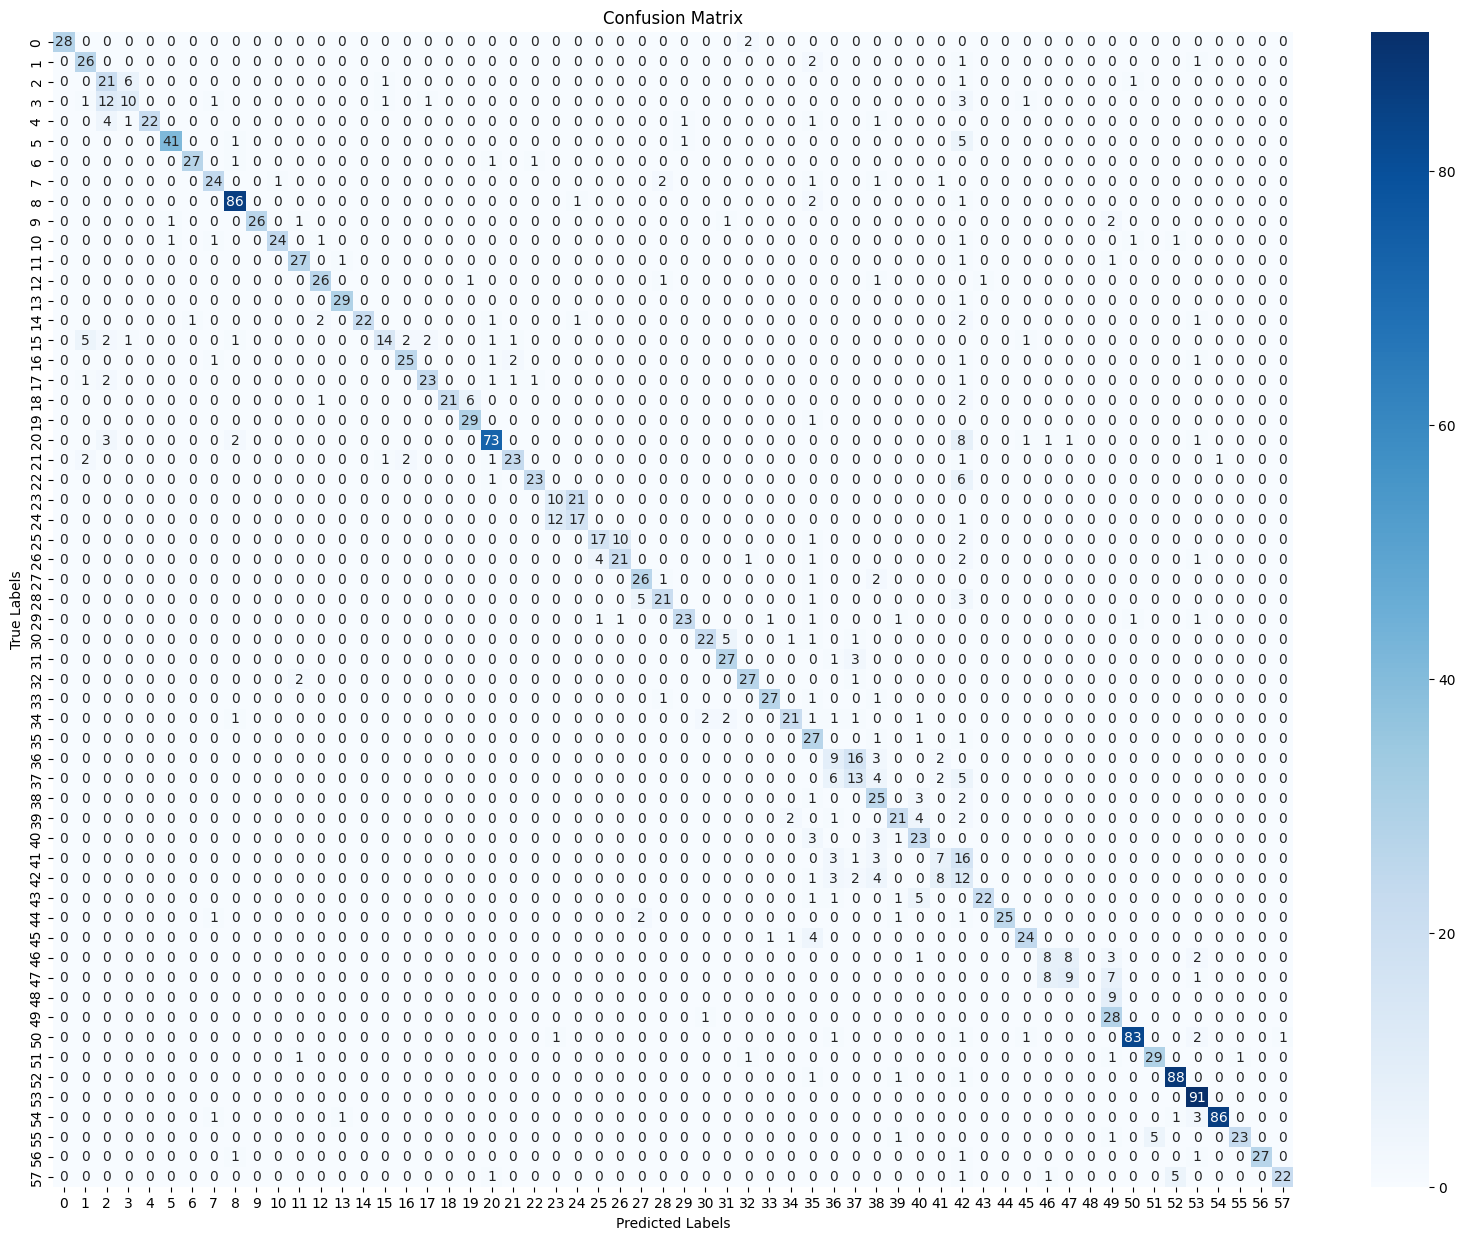


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.74      0.87      0.80        30
           2       0.48      0.70      0.57        30
           3       0.56      0.33      0.42        30
           4       1.00      0.73      0.85        30
           5       0.95      0.85      0.90        48
           6       0.96      0.90      0.93        30
           7       0.83      0.80      0.81        30
           8       0.92      0.96      0.94        90
           9       1.00      0.84      0.91        31
          10       0.96      0.80      0.87        30
          11       0.87      0.90      0.89        30
          12       0.87      0.87      0.87        30
          13       0.94      0.97      0.95        30
          14       1.00      0.73      0.85        30
          15       0.82      0.47      0.60        30
          16       0.86      0.81      0.83        31
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ------------------------------
# Predict on test data
# ------------------------------

y_pred = model.predict(X_test)

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot encoded test labels back to integers
y_true = np.argmax(y_test, axis=1)
# Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
# Plot Confusion Matrix

plt.figure(figsize=(20,15))

sns.heatmap(
    cm,
    cmap='Blues',
    annot=True,
    fmt='d'

)

plt.title('Confusion Matrix')

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.show()

# Classification Report
# ------------------------------

print("\nClassification Report:\n")

print(classification_report( y_true,y_pred_classes))

### **5.1 ResNet vs CNN**

Two deep learning approaches were implemented in this project: a custom Convolutional Neural Network (CNN) and a Transfer Learning model based on ResNet50. The CNN model was developed from scratch and served as a baseline for traffic sign classification. In contrast, ResNet50 leveraged pre-trained weights from the ImageNet dataset, enabling it to learn discriminative features more effectively.

Experimental results indicate that ResNet50 outperformed the CNN model in terms of classification accuracy and generalization capability. The utilization of transfer learning allowed ResNet50 to converge faster and produce more reliable predictions on unseen traffic sign images.

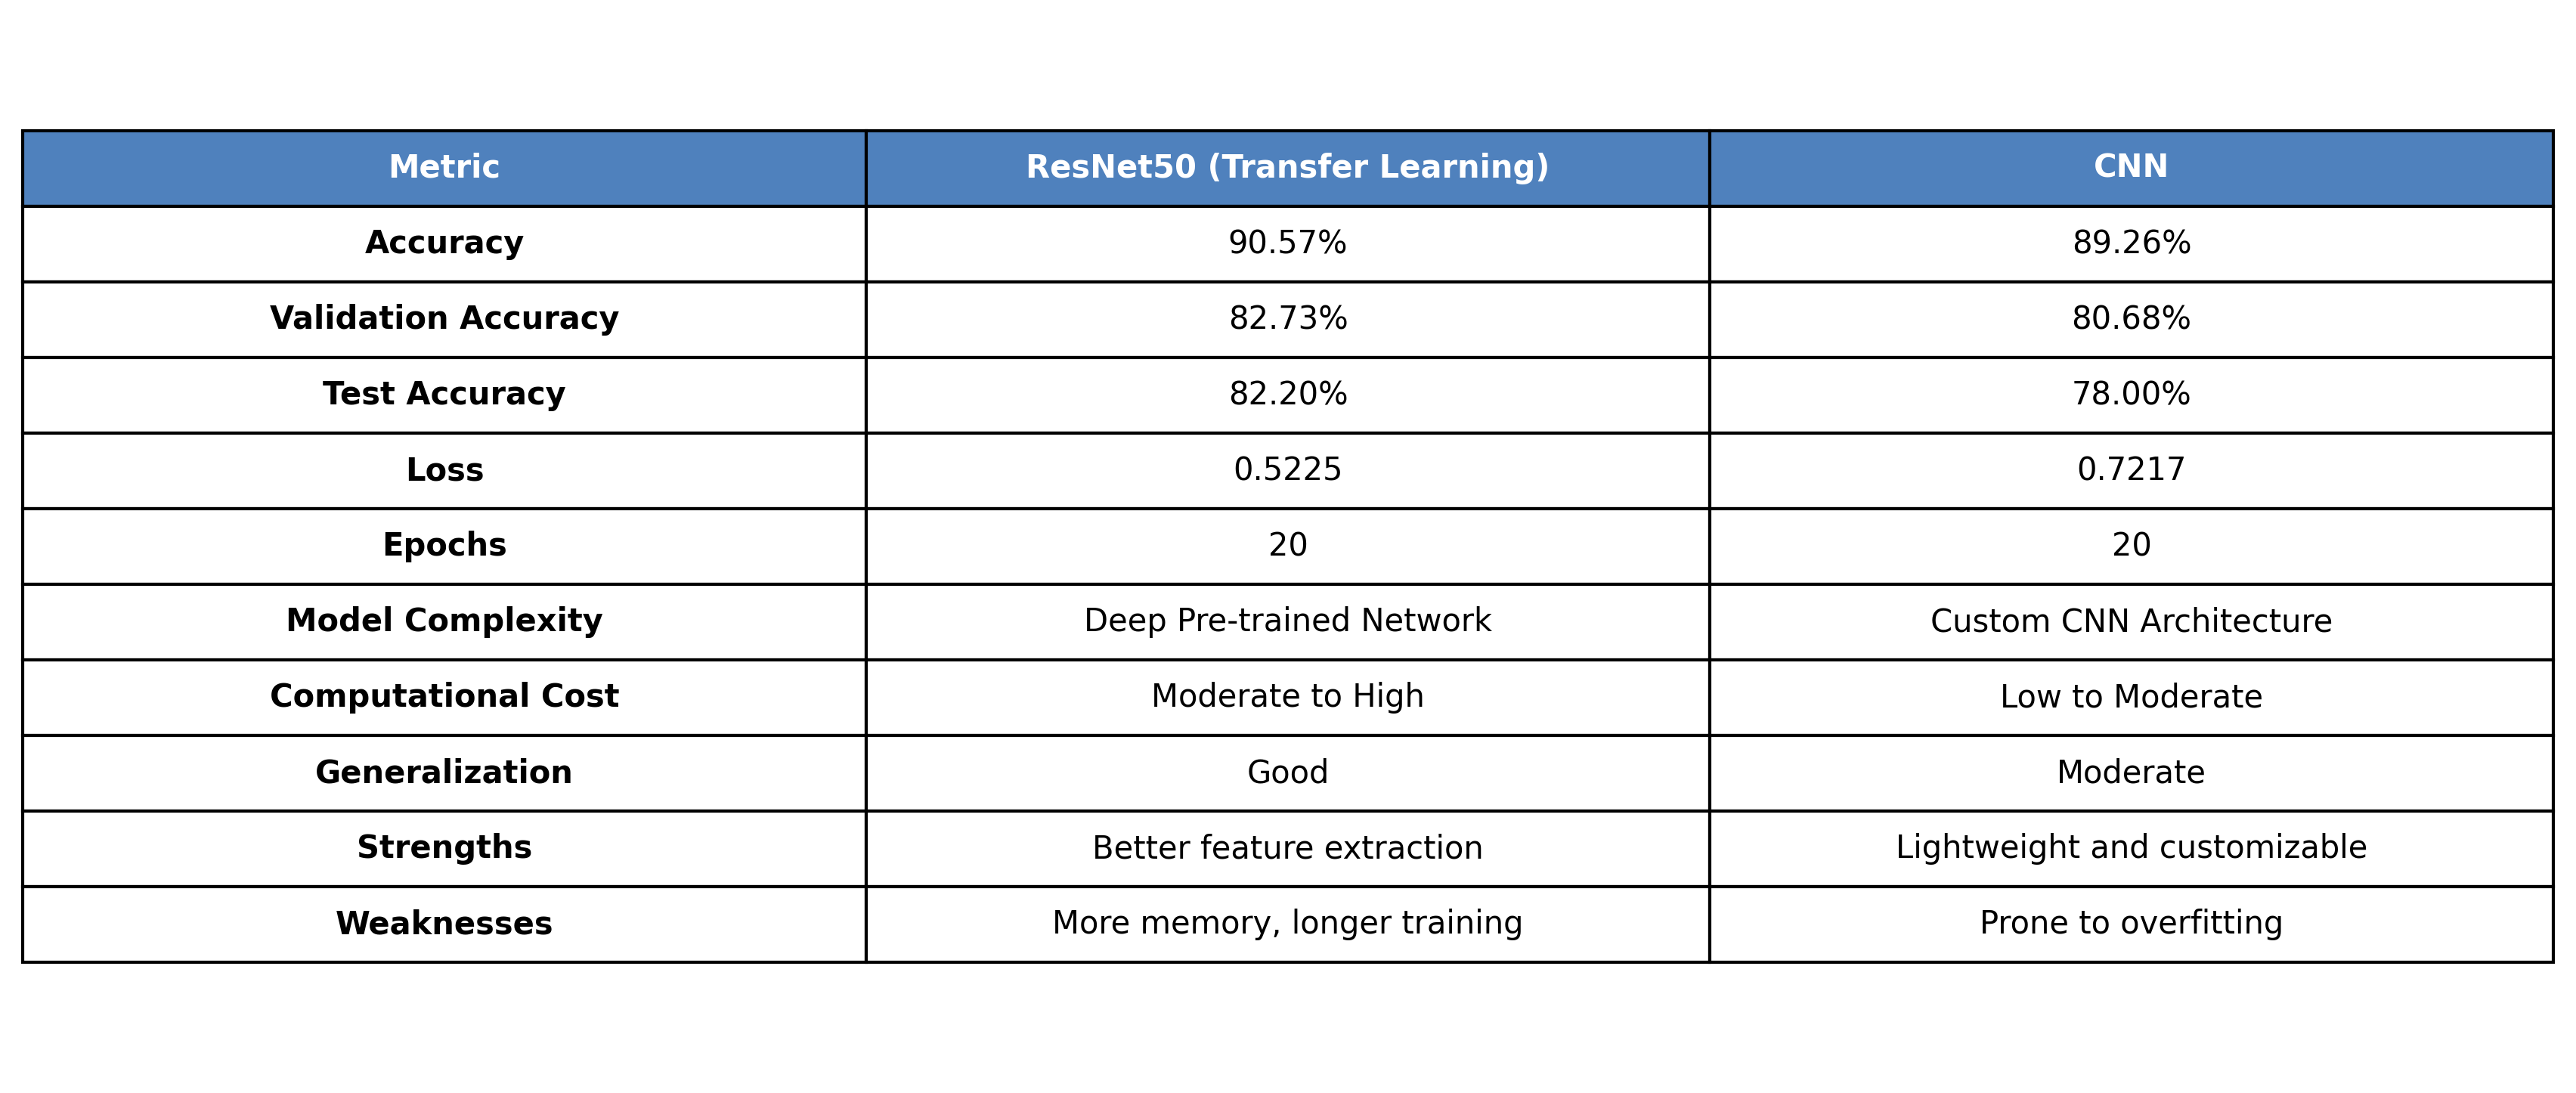

## 5.2 Accuracy Comparison

The performance comparison between the CNN and ResNet50 models indicates that the ResNet50 model achieved superior classification performance. The ResNet50 model obtained a test accuracy of 82.20%, whereas the CNN model achieved 78.00% accuracy. The use of transfer learning and pre-trained ImageNet weights enabled ResNet50 to learn more discriminative visual features, resulting in improved recognition of traffic sign categories.


## 5.3 Computational Efficiency Comparison

Although the CNN model required fewer computational resources and involved a simpler architecture, it exhibited comparatively lower classification performance.

In contrast, ResNet50 demanded additional memory and training time due to its deeper architecture but demonstrated better feature extraction capabilities and stronger generalization performance.

Therefore, ResNet50 provides a better trade-off between computational cost and prediction accuracy for traffic sign recognition taskss.


## 6. Challenges Faced

Several challenges were encountered during the development and training of the CNN-based traffic sign recognition system.

One of the major challenges was handling variations in traffic sign appearances caused by differences in illumination, viewing angles, background clutter, and weather conditions.

Another challenge was preventing overfitting, as the model exhibited a gap between training and validation performance.

Fine-tuning hyperparameters such as learning rate, batch size, and dropout rate was necessary to achieve stable convergence and improve the model's generalization capability.


## 7. Key Learnings

This project provided valuable practical experience in deep learning and computer vision. The major learnings obtained from this work include:

Understanding the working principles of Convolutional Neural Networks (CNNs)

Learning image preprocessing techniques such as resizing, normalization, and augmentation.

Gaining knowledge about Batch Normalization and Dropout for improving model performance.

Understanding evaluation metrics including accuracy, precision, recall, F1-score, and confusion matrices.

Developing skills in hyperparameter tuning and analyzing training and validation curves.

Understanding the importance of balancing model complexity and computational efficiency.

##8. Future Scope

The proposed CNN-based traffic sign recognition system can be further enhanced in several ways:

Increasing the size and diversity of the training dataset to improve classification performance.

Applying advanced data augmentation techniques to reduce overfitting.

Incorporating deeper CNN architectures to extract more discriminative image features.

Implementing real-time traffic sign detection using object detection models such as YOLO.

Deploying the trained model on edge devices or mobile platforms for intelligent transportation applications.

Integrating the system with Advanced Driver Assistance Systems (ADAS) and autonomous vehicles.

## 9. Conclusion

In this project, a Convolutional Neural Network (CNN) was developed for traffic sign recognition using Indian traffic sign images. The model was trained and evaluated on a dataset containing 59 traffic sign classes. Experimental results demonstrated that the CNN model achieved a training accuracy of 89.26%, a validation accuracy of 80.68%, and an overall test accuracy of 78.00%.

The results indicate that CNNs are capable of learning meaningful visual features and performing multi-class traffic sign classification effectively. Although the model exhibited slight overfitting, it provided satisfactory classification performance and served as a strong baseline approach for comparison with transfer learning techniques.




## **10. References**

[1] Neel and Pratiksha, "Indian Traffic Sign Dataset," Kaggle, 2021.

[2] Martín Abadi et al., "TensorFlow: Large-Scale Machine Learning on Heterogeneous Systems," 2015.

[3] François Chollet et al., "Keras," GitHub Repository, 2015.

[4] Bradski, G., "The OpenCV Library," Dr. Dobb's Journal of Software Tools, 2000.

[5] He, K., Zhang, X., Ren, S., and Sun, J., "Deep Residual Learning for Image Recognition," Proceedings of CVPR, 2016.